# QR-DQN: regress fixed return quantiles

QR-DQN predicts quantile locations $\theta_i(s,a)$ and minimizes
$$\mathcal L=\frac1{N^2}\sum_{i,j}\rho_{\tau_i}^{\kappa}\left(y_j-\theta_i(s,a)\right).$$
Here $\tau_i=(i+1/2)/N$ is a quantile level, $y_j$ a target quantile, and $\rho^\kappa_\tau$ the asymmetric quantile Huber loss.

## 1. Predict quantile locations

Unlike C51, probabilities are fixed and the atom locations move.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

QUANTILES = 51
KAPPA = 1.0
taus = (torch.arange(QUANTILES, dtype=torch.float32) + 0.5) / QUANTILES

class QuantileNetwork(nn.Module):
    def __init__(self, observations=4, actions=2):
        super().__init__(); self.actions = actions
        self.model = nn.Sequential(nn.Linear(observations, 64), nn.ReLU(), nn.Linear(64, actions * QUANTILES))
    def forward(self, observations):
        return self.model(observations).view(-1, self.actions, QUANTILES)

network = QuantileNetwork()
optimizer = torch.optim.Adam(network.parameters(), lr=1e-3)

## 2. Implement quantile Huber loss

Pair every predicted quantile with every target quantile; the quantile weight makes under- and overestimation asymmetric.

In [2]:
def quantile_huber(predicted, target):
    errors = target[:, None, :] - predicted[:, :, None]
    absolute = errors.abs()
    huber = torch.where(absolute <= KAPPA, 0.5 * errors.square(), KAPPA * (absolute - 0.5 * KAPPA))
    weights = (taus[None, :, None] - (errors.detach() < 0).float()).abs()
    return (weights * huber / KAPPA).mean()

observations = torch.randn(8, 4)
actions = torch.randint(2, (8,))
predicted = network(observations)[torch.arange(8), actions]
target = torch.randn(8, QUANTILES) + 1.0
loss = quantile_huber(predicted, target)
optimizer.zero_grad(); loss.backward(); optimizer.step()

/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce GTX 960M which is of compute capability (CC) 5.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:602: UserWarning: 
NVIDIA

## 3. Inspect the learned representation

Sorted quantile locations describe a return distribution with equal probability mass between neighboring levels.

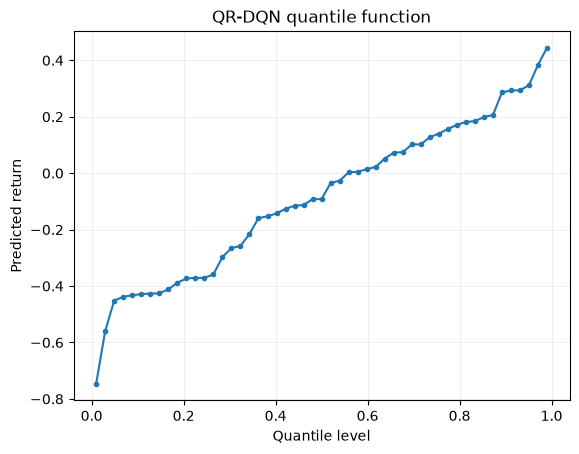

In [3]:
with torch.no_grad():
    quantiles = network(observations[:1])[0, 0].sort().values.numpy()
plt.plot(taus.numpy(), quantiles, marker=".")
plt.xlabel("Quantile level")
plt.ylabel("Predicted return")
plt.title("QR-DQN quantile function")
plt.grid(alpha=0.2); plt.show()